# This notebook walks through stochastic extracellular stimulation

In [1]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import matplotlib.pyplot as plt
import sys

In [2]:
h.chdir("/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src")

if sys.platform.startswith('linux'): # LINUX
    h.nrn_load_dll('../nrn/x86_64/.libs/libnrnmech.so') 
    
h.load_file('stdrun.hoc')

1.0

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [3]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Build just a simple, very long axonal compartment

In [4]:
# Axon dimensions 
L = 2000 # [um]
d = 2 # [um]
dx = 5 # [um]

# Create new axon 
axon = h.Section(name='axon')
h.pt3dadd(-L/2, 0, 0, d, sec=axon)
h.pt3dadd(L/2, 0, 0, d, sec=axon)
axon.nseg = int(L/dx)

### Set up biophysics 

In [8]:
axon.insert('pas')
axon.insert('mammalian_spike_35')
axon.insert('cad')

# First, define some global params
axon.Ra = 143.2 # [Ohm-cm]
axon.cm = 1 # [uF/cm2]
axon.ena = 60.6 # [mV]
axon.ek = -101.34 # [mV]
axon.e_pas = -67 # [mV]

# Next, define ion channel densities 
axon.gnabar_mammalian_spike_35 = 420*(1e-3) # [S/cm2]
axon.gkbar_mammalian_spike_35 = 50*(1e-3) # [S/cm2]
axon.gcabar_mammalian_spike_35 = 0*(1e-3) # [S/cm2]
axon.gkcbar_mammalian_spike_35 = 0.31*(1e-3) # [S/cm2]
axon.g_pas = .2*(1e-3) # [S/cm2]

# # Next, define ion channel densities 
# axon.gnabar_mammalian_spike_35 = 100*(1e-3) # [S/cm2]
# axon.gkbar_mammalian_spike_35 = 50*(1e-3) # [S/cm2]
# axon.gcabar_mammalian_spike_35 = 0.75*(1e-3) # [S/cm2]
# axon.gkcbar_mammalian_spike_35 = 0.2*(1e-3) # [S/cm2]
# axon.g_pas = .1*(1e-3) # [S/cm2]

# # Next, define ion channel densities 
# axon.gnabar_mammalian_spike_35 = 100*(1e-3) # [S/cm2]
# axon.gkbar_mammalian_spike_35 = 50*(1e-3) # [S/cm2]
# axon.gcabar_mammalian_spike_35 = 0.75*(1e-3) # [S/cm2]
# axon.gkcbar_mammalian_spike_35 = 0.1*(1e-3) #0.2*(1e-3) # [S/cm2]
# axon.g_pas = .1*(1e-3) # [S/cm2]

### Setup extracellular mechanism 

In [9]:
axon.insert('extracellular')
axon.insert('xtra')

# Allocate memory to compute segment centers 
n3d = int(h.n3d(sec=axon))
xx = h.Vector(n3d)
yy = h.Vector(n3d)
zz = h.Vector(n3d)
dd = h.Vector(n3d)
ll = h.Vector(n3d)

# Get xyz coordiantes, diameter and length along section
for i in range(0,n3d):
    xx.x[i] = h.x3d(i,sec=axon)
    yy.x[i] = h.y3d(i,sec=axon)
    zz.x[i] = h.z3d(i,sec=axon)
    dd.x[i] = h.diam3d(i,sec=axon)
    ll.x[i] = h.arc3d(i,sec=axon)

# Interpolate to the geometric centers of each segment of the section
ll.div(axon.L)

rint = h.Vector(axon.nseg+2)
rint.indgen(1./axon.nseg)
rint.sub(1./(2.*axon.nseg))
rint.x[0] = 0
rint.x[axon.nseg+1] = 1

xint = h.Vector(axon.nseg+2)
yint = h.Vector(axon.nseg+2)
zint = h.Vector(axon.nseg+2)
dint = h.Vector(axon.nseg+2)
xint.interpolate(rint,ll,xx)
yint.interpolate(rint,ll,yy)
zint.interpolate(rint,ll,zz)
dint.interpolate(rint,ll,dd)

# Set centers in xtra mechanism
for i in range(1,axon.nseg+1):
    axon(rint.x[i]).xtra.x = xint.x[i]
    axon(rint.x[i]).xtra.y = yint.x[i]
    axon(rint.x[i]).xtra.z = zint.x[i]
    axon(rint.x[i]).xtra.d = dint.x[i]

## Step 2: setup stimulus and transfer resistances 

In [10]:
# membrane voltage to initialize the model (mV)
vInit = -69 # -69

# stimulus parameters 
I = -0 # [uA]
elecType = 'disk'
dDisk = 15 # [um]
rhoExt = 1000 # [Ohm-cm]
elecLoc = [0,0,15] # [um]
pulseShape = 'tri'
pulseRatioTri = [-2/3,1,-1/3]

# temporal parameters 
tInitStop = 100 # [ms]
tInitDt = 1 # [ms]
tStop = 20 # [ms]
tDt = 0.005 # [ms]
tDel = 1 # [ms]
tDur = 0.05 # [ms]

### set up triphasic pulse 

In [11]:
def setup_pulse(I):
    tsvec = h.Vector(np.concatenate(([0,0],tInitStop+np.linspace(0,tStop,int(tStop/tDt)+1))))
    isvec = np.zeros(int(2+tStop/tDt)+1)
    if pulseShape=='tri':
        isvec[int(tDel/tDt)+2:int((tDel+tDur)/tDt)+3] = I*pulseRatioTri[0]
        isvec[int((tDel+tDur)/tDt+2):int((tDel+2*tDur)/tDt)+3] = I*pulseRatioTri[1]
        isvec[int((tDel+2*tDur)/tDt+2):int((tDel+3*tDur)/tDt)+3] = I*pulseRatioTri[2]
    return tsvec,isvec

tsvec,isvec = setup_pulse(I)

### set up transfer resistances at axonal segments

In [12]:
# Loop over all segments in section and specify transfer impedance
for seg in axon:
    # Compute extracellular potentials depending on electrode type
    if elecType=='point':
        # Compute distance from electrode to center of each segment
        dist = 1e-4*\
                np.sqrt((seg.xtra.x - (elecLoc[0]))**2 + \
                        (seg.xtra.y - (elecLoc[1]))**2 + \
                        (seg.xtra.z - (elecLoc[2]))**2)
        seg.xtra.rx = 1e-6*rhoExt/(4.0*np.pi*dist)
    elif elecType=='disk':
        # Axial and radial distance for each compartment center (cm)
        r = 1e-4*\
                np.sqrt((seg.xtra.x - (elecLoc[0]))**2\
                        + (seg.xtra.y - (elecLoc[1]))**2)
        z = 1e-4*(seg.xtra.z-elecLoc[2])
        # Analytical potentials (disk electrode) for given distance
        rDisk = 1e-4*dDisk/2 # in cm
        # Set transfer impedance for each segment
        seg.xtra.rx  = 1e-6*(2.0*rhoExt)/(4.0*np.pi*rDisk) * np.arcsin((2*rDisk) / (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2))) # in 1e-6*Ohm*cm/cm==MOhm

    # Map references of extracellular and membrane current with xtra mechanism
    h.setpointer(axon(seg.x)._ref_e_extracellular,'ex',axon(seg.x).xtra)
    h.setpointer(axon(seg.x)._ref_i_membrane,'im',axon(seg.x).xtra)

## Step 3: Setup outputs and run the sim 

### time vector

In [13]:
tRec = h.Vector().record(h._ref_t)

### voltage vector at each segment

In [14]:
vRec = []
for i in range(axon.nseg):
    vRec.append(h.Vector().record(axon(1/axon.nseg+i/axon.nseg)._ref_v))    

### run the simulation

In [15]:
isvec = h.Vector(isvec)*1e-3  # conversion from uA to mA necessary
isvec.play(h._ref_is_xtra,tsvec,1) 

# Init
h.tstop = tInitStop
h.dt = tInitDt
h.finitialize(vInit)
h.continuerun(h.tstop)
# Run
h.tstop = tInitStop+tStop
h.dt = tDt
h.continuerun(h.tstop)

0.0

## Step 3: Inspect output

In [16]:
print(vRec[0][int(tInitStop/tInitDt)])
print(vRec[0][int(tInitStop/tInitDt + 5/tDt)])
print(vRec[0][int(tInitStop/tInitDt + 10/tDt)])
print(vRec[0][int(tInitStop/tInitDt + 15/tDt)])
print(vRec[0][int(tInitStop/tInitDt + 20/tDt)])

-68.76457038986135
-68.6879903859639
-68.61910698783913
-68.55562840797282
-68.49577540644921


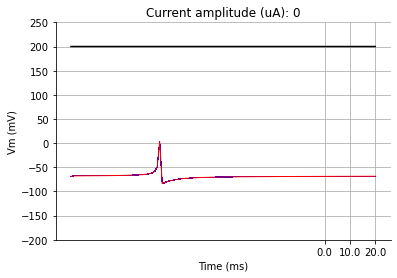

In [17]:
# Membrane voltage over time
fig = plt.figure()
ax = fig.add_subplot(111)
ax.grid()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
for i in range(axon.nseg):
    plt.plot(tRec,vRec[i],'b',linewidth=0.25)
plt.plot(tRec,vRec[int(axon.nseg/2)],'r',linewidth=1)
plt.plot(tsvec,isvec*(1e3)*5+200,'k')
ticksPerMs = 0.1
plt.xticks(np.linspace(tInitStop,tInitStop+tStop, num=int(tStop*ticksPerMs+1)),
            np.linspace(tInitStop,tInitStop+tStop, num=int(tStop*ticksPerMs+1))-tInitStop)
# plt.xlim(tInitStop,tInitStop+tStop)
plt.ylim(-200,250)
plt.xlabel('Time (ms)')
plt.ylabel('Vm (mV)')
plt.title('Current amplitude (uA): ' + str(I))
plt.show()

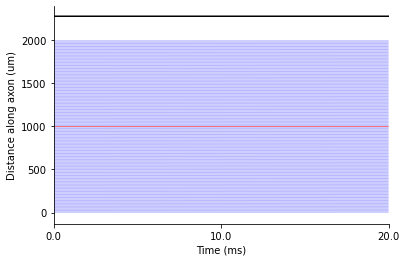

In [18]:
# Membrane voltage over space
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
offset = -vInit
for i in range(axon.nseg):
    if i==axon.nseg/2:
        plt.plot(tRec,vRec[i]+offset,'r',linewidth=0.5)
    else:
        plt.plot(tRec,vRec[i]+offset,'b',linewidth=0.1)
    offset += dx
plt.plot(tsvec,isvec*(1e3)*50+offset*1.1,'k')
ticksPerMs = 0.1
plt.xticks(np.linspace(tInitStop,tInitStop+tStop, num=int(tStop*ticksPerMs+1)),
            np.linspace(tInitStop,tInitStop+tStop, num=int(tStop*ticksPerMs+1))-tInitStop)
plt.xlim(tInitStop,tInitStop+tStop)
plt.xlabel('Time (ms)')
plt.ylabel('Distance along axon (um)')
plt.show()

## Step 4: For arbitrary electrode location, calculate threshold 

In [19]:
epsilon = 0.01
currents = np.logspace(0,4,25,base=2) - 1
threshold = np.inf


for ii,current in enumerate(currents):
    vRec = []
    for i in range(axon.nseg):
        vRec.append(h.Vector().record(axon(1/axon.nseg+i/axon.nseg)._ref_v))   

    I = -1 * float(current)
    print('Testing current: ',I)

    tsvec,isvec = setup_pulse(I)
    isvec = h.Vector(isvec)*1e-3  # conversion from uA to mA necessary
    isvec.play(h._ref_is_xtra,tsvec,1) 

    # Init
    h.tstop = tInitStop
    h.dt = tInitDt
    h.finitialize(vInit)
    h.continuerun(h.tstop)
    # Run
    h.tstop = tInitStop+tStop
    h.dt = tDt
    h.continuerun(h.tstop)

    vRec = np.array(vRec)
    print(vRec[-1][100:].max() > 0)

    if (vRec[-1][100:].max() > 0):

        threhsold = current

        # Now, do a bisection search 
        upBound = current
        lowBound = currents[ii-1]
        error = upBound-lowBound 

        while error > epsilon: 
            scaling_var = lowBound+((upBound-lowBound)/2) 

            print("Starting trial with",str(scaling_var),"upper bound =",\
                    str(upBound),"lower bound =",str(lowBound))
            
            I = -1 * scaling_var
            
            tsvec,isvec = setup_pulse(I)
            isvec = h.Vector(isvec)*1e-3  # conversion from uA to mA necessary
            isvec.play(h._ref_is_xtra,tsvec,1)

            vRec_axon_1 = []
            for seg in axon:
                vRec_axon_1.append(h.Vector().record(axon(seg.x)._ref_v))

            # Init
            h.tstop = tInitStop
            h.dt = tInitDt
            h.finitialize(vInit)
            h.continuerun(h.tstop)
            # Run
            h.tstop = tInitStop+tStop
            h.dt = tDt
            h.continuerun(h.tstop)
            
            vRec_axon_1 = np.array(vRec_axon_1)
            if (vRec_axon_1[-1][100:].max() > 0):
                upBound = scaling_var 
                threshold = scaling_var
                vRec = vRec_axon_1.copy() # cast copy to save
            else:
                lowBound = scaling_var

            error = upBound-lowBound

        print('Lower threshold found at: ', str(threshold), ' uA')
        break

Testing current:  -0.0
False
Testing current:  -0.12246204830937302
False
Testing current:  -0.2599210498948732
False
Testing current:  -0.41421356237309515
False
Testing current:  -0.5874010519681994
False
Testing current:  -0.7817974362806785
False
Testing current:  -1.0
True
Starting trial with 0.8908987181403393 upper bound = 1.0 lower bound = 0.7817974362806785
Starting trial with 0.836348077210509 upper bound = 0.8908987181403393 lower bound = 0.7817974362806785
Starting trial with 0.8090727567455938 upper bound = 0.836348077210509 lower bound = 0.7817974362806785
Starting trial with 0.7954350965131362 upper bound = 0.8090727567455938 lower bound = 0.7817974362806785
Starting trial with 0.7886162663969074 upper bound = 0.7954350965131362 lower bound = 0.7817974362806785
Lower threshold found at:  0.7954350965131362  uA


## Step 5: Inject some noise into the membrane current

In [ ]:
### --- inject Gaussian noise into axon
tstop = 80
dt = 0.005
current = 2.591
random_stream_offset_ = (tstop+1000)*1/dt * np.floor(current*(1e-3)*10)
r = h.Random()
trials = 6
knoise = 0.00025*(1e3)
spikes = 0
for k in range(trials):
    ## --- Inject noise into distal axon
    objs = [h.InGauss(seg.x,sec=RGC.axon) for seg in RGC.axon]
    for obj in objs:
        r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
        segment = obj.get_segment()

        obj.delay = 0
        obj.dur = tstop
        obj.mean = 0
        # TODO: change whether axonal or somatic
        obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
                        * segment.gnabar_mammalian_spike_35*1e3))
        obj.noiseFromRandom(r)

        # print('axon noise std: ', obj.stdev)
        
    h.setpointers()

    # ## --- Inject noise into sodium channel band
    # objs_socb = [h.InGauss(seg.x,sec=RGC.SOCB) for seg in RGC.SOCB]
    # for obj in objs_socb:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     *segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)

    #     # print('socb noise std: ', obj.stdev)

    # h.setpointers()

    # objs_ah = [h.InGauss(seg.x,sec=RGC.AH) for seg in RGC.AH]
    # for obj in objs_ah:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     * segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)
    
    #     # print('ah std: ', obj.stdev)
        
    # h.setpointers()

    # objs_soma = [h.InGauss(seg.x,sec=RGC.cell.soma) for seg in RGC.cell.soma]
    # for obj in objs_soma:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     * segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)

    #     # print('soma std: ', obj.stdev)
        
    # h.setpointers()

    ## -- set up recording vectors
    APC_axon = h.APCount(1, sec = RGC.axon)
    APC_axon.thresh = 0 

    vRec_axon = []
    for seg in RGC.axon:
        vRec_axon.append(h.Vector().record(RGC.axon(seg.x)._ref_v))

    ## -- run simulation
    # Stim['amp'] = Stim['polarity']*float(current)
    # tsvec, isvec = hf.setupStimulus(Stim)
    tsvec, isvec = hf.setupStimulus_unit(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)

    ## -- if spike, increment spike count
    if APC_axon.n > 0:
        spike_timing = APC_axon.time
        if spike_timing > 50 and spike_timing < 70:
            spikes += 1
            print('SPIKE: Current: ', current, 'uA, Spikes: ', spikes, '/', k+1)
        else:
            print('SPIKE TIME NOT MET: Current: ', current, 'uA, Spikes: ', spikes, '/', k+1)
            continue
    else:
        print('NO SPIKE: Current: ', current, 'uA, Spikes: ', spikes, '/', k+1)

## Step 5: Visualize what happened

### Extracellular recording as observed from a given recording electrode (point source approx)

In [ ]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-600,0,35]

# setup vector where to store extracellular voltage profile
if stim_type == 'clamp':
    timeStepsRec = int(h.tstop/h.dt)+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))
elif stim_type == 'extra':
    timeStepsRec = int(Stim['stop']/Stim['dt'])+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Compute distance from electrode to center of each segment [um]
        dist = np.sqrt((seg.xtra.x-recElec[0])**2 + (seg.xtra.y-recElec[1])**2 \
                       + (seg.xtra.z-recElec[2])**2)
        
        # Set transfer impedance for each segment [MOhm]
        tf = Stim['rhoExt'] / (4.0*np.pi*dist*(1e-4)) * 1e-6

        # recOut units: 1e3*MOhm*nA == uV
        if stim_type == 'clamp':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy())
        elif stim_type == 'extra':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

In [ ]:
# Plot extracellular voltaged recorded on recElec
if stim_type == 'clamp':
    plt.plot(np.arange(0,h.tstop+h.dt,h.dt),recOut)
    # do some adaptive peak finding to zoom in on spike
    peak_time = t[recOut.argmin()]
    plt.xlim(0,peak_time+2)
elif stim_type == 'extra':
    plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
    plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Now try with disk electrode approximations

In [ ]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-200,0,45]

# setup vector where to store extracellular voltage profile
if stim_type == 'clamp':
    timeStepsRec = int(h.tstop/h.dt)+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))
elif stim_type == 'extra':
    timeStepsRec = int(Stim['stop']/Stim['dt'])+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))

print(recOut)


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Distance from electrode to center of each segment [cm]
        r = 1e-4*\
            np.sqrt((seg.xtra.x - (recElec[0]))**2\
                    + (seg.xtra.y - (recElec[1]))**2)
        # Vertical distance [cm]
        z = 1e-4*(seg.xtra.z-recElec[2])

        # Transfer impedance [MOhm]  
        rDisk = 1e-4*Stim['elecDiam']/2             
        tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
            * np.arcsin((2*rDisk) / \
            (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                    
        # recOut units: 1e3*MOhm*nA == uV
        if stim_type == 'clamp':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy())
        elif stim_type == 'extra':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

In [ ]:
# Plot extracellular voltaged recorded on recElec
if stim_type == 'clamp':
    plt.plot(np.arange(0,h.tstop+h.dt,h.dt),recOut)
    # do some adaptive peak finding to zoom in on spike
    peak_time = t[recOut.argmin()]
    plt.xlim(0,peak_time+2)
elif stim_type == 'extra':
    plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
    plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')